In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 500

<Figure size 640x480 with 0 Axes>

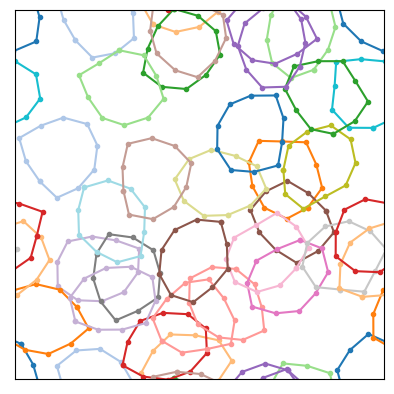

In [3]:
numPolygons = 32
n = 10
nVals = [0, 1, 2, 3, 9, 4 ,5, 6, 20, 25, 35, 54]
i = 5
phi = 1.0
kappa = 3.7
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")

m.generateRandomPolygons(numPolygons, n, kappa = kappa, phi = phi)
#modelDir = "playersTesting/" + str(np.max(np.array(os.listdir("playersTesting")).astype(int)))
#m.loadModel(modelDir)
plt.clf()

m.setStiffness(1)
m.setMaxEdgeLength()

newPositions = m.getPositions() + np.random.randn(m.getNumVertices() * 2) * 0.001 + 1
m.setPositions(newPositions % 1)
#m.loadModel("parallel")
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.updateConstraintForces()
force0 = m.getConstraintForces()
positions0 = m.getPositions()# Now you have dA, can you draw arrows on the vertices?
artists = m.draw()

In [4]:
m.updatePolygonGeometry()
m.getAreas()

array([0.03133166, 0.03143422, 0.03128503, 0.03145078, 0.0317268 ,
       0.03143527, 0.03153182, 0.03110122, 0.03140875, 0.03111069,
       0.0313183 , 0.03132158, 0.03112358, 0.03104853, 0.03109621,
       0.03121412, 0.03102652, 0.03124351, 0.03156927, 0.03133156,
       0.03095182, 0.03114686, 0.03129473, 0.03127169, 0.0310496 ,
       0.03124654, 0.03125306, 0.03132821, 0.03141923, 0.03137633,
       0.03100352, 0.03103959])

In [5]:
m.setTargetAreas(np.ones(m.getNumPolygons()) * (1.0 / m.getNumPolygons()))
m.resetAreas()
m.updatePolygonGeometry()

In [6]:
m.getAreas()

array([0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
       0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
       0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
       0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125, 0.03125,
       0.03125, 0.03125, 0.03125, 0.03125])

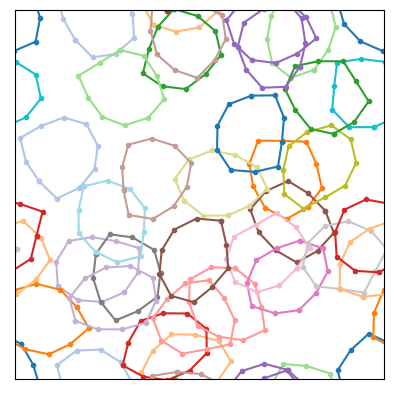

In [11]:
_ = m.draw()

In [12]:
m.updatePolygonGeometry()
m.getAreas()

array([0.03125   , 0.03125   , 0.03125   , 0.03125   , 0.03125   ,
       0.03125   , 0.03125   , 0.03125   , 0.03125   , 0.03125   ,
       0.03125   , 0.03125   , 0.03125   , 0.03125   , 0.03125   ,
       0.03125   , 0.03125   , 0.03125   , 0.03125   , 0.03125   ,
       0.03125   , 0.03125   , 0.03125   , 0.03125   , 0.03125   ,
       0.03133064, 0.03124509, 0.03127226, 0.03149295, 0.03151284,
       0.031334  , 0.03088634])

In [13]:
com = m.getCOM()
comX = com[:m.getNumPolygons()]
comY = com[m.getNumPolygons():]

In [14]:
positions

array([0.29397984, 0.51040553, 0.30798777, 0.44421849, 0.37340636,
       0.43331557, 0.42942588, 0.46762239, 0.46504715, 0.52006537,
       0.47735656, 0.58436209, 0.43200321, 0.63146217, 0.37021882,
       0.65096465, 0.30707204, 0.63433161, 0.29041907, 0.57405337])

In [15]:
comx

0.3746916703955

In [16]:
comX

array([0.97511293, 0.22158985, 0.73017365, 0.46196981, 0.45006977,
       0.77136779, 0.40774748, 0.57279579, 0.69083043, 0.22308859,
       0.74980155, 0.46640526, 0.73694569, 0.68123096, 0.29996436,
       0.8899225 , 0.81887485, 0.55518316, 0.9566989 , 0.26313829,
       0.64136591, 0.12334205, 0.07573898, 0.9816761 , 0.84157246,
       0.29157787, 0.9675791 , 0.48864945, 0.69924035, 0.26837832,
       0.48579054, 0.37469167])

In [8]:
m.minimizeGD(dt = 1e-6, maxSteps = maxSteps, progressBar = True)

Processing: 100%|███████████████████████████| 500/500 [00:00<00:00, 1082.73it/s]


In [ ]:
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors()
m.updateOutersections()
m.updateForceEnergy()
force = m.getForces()
m.updateConstraintForces()
force0 = m.getConstraintForces()
positions0 = m.getPositions()# Now you have dA, can you draw arrows on the vertices?
artists = m.draw(forces = force0, arrowColor = 'r')

In [ ]:
print(m.getEnergy())

In [ ]:
m.getMaxUnbalancedForce()

In [ ]:
np.mean(m.getAreas()), np.std(m.getAreas())

In [ ]:
m.saveModel("badForces", overwrite = True)

In [ ]:
0.7147665882227807